In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("parking_cleaned1.csv")
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour,DemandLevel
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,0.105719,10.571924,516,2016-10-04,7,59,1,Tuesday,0,0,Low
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,0.110919,11.091854,513,2016-10-04,8,25,1,Tuesday,0,0,Low
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42,0.138648,13.864818,497,2016-10-04,8,59,1,Tuesday,0,0,Low
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46,0.185442,18.544194,470,2016-10-04,9,32,1,Tuesday,0,1,Low
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48,0.259965,25.996534,427,2016-10-04,9,59,1,Tuesday,0,1,Low


In [3]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

In [4]:
df = df.sort_values(["SystemCodeNumber", "LastUpdated"]).reset_index(drop=True)

In [5]:
df[["SystemCodeNumber", "LastUpdated", "Occupancy"]].head(20)


,SystemCodeNumber,LastUpdated,Occupancy
0,BHMBCCMKT01,2016-10-04 07:59:42,61
1,BHMBCCMKT01,2016-10-04 08:25:42,64
2,BHMBCCMKT01,2016-10-04 08:59:42,80
3,BHMBCCMKT01,2016-10-04 09:32:46,107
4,BHMBCCMKT01,2016-10-04 09:59:48,150
5,BHMBCCMKT01,2016-10-04 10:26:49,177
6,BHMBCCMKT01,2016-10-04 10:59:48,219
7,BHMBCCMKT01,2016-10-04 11:25:47,247
8,BHMBCCMKT01,2016-10-04 11:59:44,259
9,BHMBCCMKT01,2016-10-04 12:29:45,266


In [6]:
# creating time features
df["Hour"] = df["LastUpdated"].dt.hour
df["Minute"] = df["LastUpdated"].dt.minute
df["DayOfWeek"] = df["LastUpdated"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
df["Date"] = df["LastUpdated"].dt.date

In [7]:
df["HourSin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
)

df["HourCos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
)

In [8]:
df["DaySin"] = np.sin(
    2 * np.pi * df["DayOfWeek"] / 7
)

df["DayCos"] = np.cos(
    2 * np.pi * df["DayOfWeek"] / 7
)

In [9]:
# Lag Features
df["Occupancy_Lag1"] = (df.groupby("SystemCodeNumber")["Occupancy"].shift(1))
df["Occupancy_Lag2"] = (df.groupby("SystemCodeNumber")["Occupancy"].shift(2))
df["Occupancy_Lag3"] = (df.groupby("SystemCodeNumber")["Occupancy"].shift(3))

In [10]:
df.groupby("SystemCodeNumber")

In [11]:
# Rolling Features
df["RollingMean_3"] = (
    df.groupby("SystemCodeNumber")["Occupancy"]
      .transform(
          lambda x: x.shift(1).rolling(3).mean()
      )
)

In [12]:
df["RollingMean_6"] = (
    df.groupby("SystemCodeNumber")["Occupancy"]
      .transform(
          lambda x: x.shift(1).rolling(6).mean()
      )
)

In [13]:
df["RollingStd_6"] = (
    df.groupby("SystemCodeNumber")["Occupancy"]
      .transform(
          lambda x: x.shift(1).rolling(6).std()
      )
)

In [14]:
# Demand trend
df["OccupancyChange"] = (
    df["Occupancy_Lag1"]
    - df["Occupancy_Lag2"]
)


In [15]:
# Occupancy rate features

df["OccupancyRate_Lag1"] = (
    df.groupby("SystemCodeNumber")["OccupancyRate"]
      .shift(1)
)

In [16]:
df["OccupancyRate_Lag2"] = (
    df.groupby("SystemCodeNumber")["OccupancyRate"]
      .shift(2)
)

In [17]:
# forecasting target

df["TargetOccupancy"] = (
    df.groupby("SystemCodeNumber")["Occupancy"]
      .shift(-1)
)

In [18]:
df[
    ["SystemCodeNumber", "LastUpdated"]
].head(20)

,SystemCodeNumber,LastUpdated
0,BHMBCCMKT01,2016-10-04 07:59:42
1,BHMBCCMKT01,2016-10-04 08:25:42
2,BHMBCCMKT01,2016-10-04 08:59:42
3,BHMBCCMKT01,2016-10-04 09:32:46
4,BHMBCCMKT01,2016-10-04 09:59:48
5,BHMBCCMKT01,2016-10-04 10:26:49
6,BHMBCCMKT01,2016-10-04 10:59:48
7,BHMBCCMKT01,2016-10-04 11:25:47
8,BHMBCCMKT01,2016-10-04 11:59:44
9,BHMBCCMKT01,2016-10-04 12:29:45


In [19]:
df["TimeDiff"] = (
    df.groupby("SystemCodeNumber")["LastUpdated"]
      .diff()
)

In [20]:
df["TimeDiff"].value_counts().head(10)

,count
TimeDiff,
0 days 00:33:00,2115
0 days 00:27:00,1793
0 days 00:27:01,1724
0 days 00:33:01,1540
0 days 00:32:59,1274
0 days 00:27:02,1254
0 days 00:26:58,1251
0 days 00:33:02,1150
0 days 00:26:00,1097


In [21]:
df[
    [
        "SystemCodeNumber",
        "LastUpdated",
        "Occupancy",
        "Occupancy_Lag1",
        "Occupancy_Lag2",
        "Occupancy_Lag3",
        "RollingMean_3",
        "RollingMean_6",
        "TargetOccupancy"
    ]
].head(20)

,SystemCodeNumber,LastUpdated,Occupancy,Occupancy_Lag1,Occupancy_Lag2,Occupancy_Lag3,RollingMean_3,RollingMean_6,TargetOccupancy
0,BHMBCCMKT01,2016-10-04 07:59:42,61,NaN,NaN,NaN,NaN,NaN,64.0
1,BHMBCCMKT01,2016-10-04 08:25:42,64,61.0,NaN,NaN,NaN,NaN,80.0
2,BHMBCCMKT01,2016-10-04 08:59:42,80,64.0,61.0,NaN,NaN,NaN,107.0
3,BHMBCCMKT01,2016-10-04 09:32:46,107,80.0,64.0,61.0,68.333333,NaN,150.0
4,BHMBCCMKT01,2016-10-04 09:59:48,150,107.0,80.0,64.0,83.666667,NaN,177.0
5,BHMBCCMKT01,2016-10-04 10:26:49,177,150.0,107.0,80.0,112.333333,NaN,219.0
6,BHMBCCMKT01,2016-10-04 10:59:48,219,177.0,150.0,107.0,144.666667,106.500000,247.0
7,BHMBCCMKT01,2016-10-04 11:25:47,247,219.0,177.0,150.0,182.000000,132.833333,259.0
8,BHMBCCMKT01,2016-10-04 11:59:44,259,247.0,219.0,177.0,214.333333,163.333333,266.0
9,BHMBCCMKT01,2016-10-04 12:29:45,266,259.0,247.0,219.0,241.666667,193.166667,269.0


In [22]:
df.isnull().sum().sort_values(
    ascending=False
)

,0
RollingMean_6,180
RollingStd_6,180
RollingMean_3,90
Occupancy_Lag3,90
Occupancy_Lag2,60
OccupancyChange,60
OccupancyRate_Lag2,60
Occupancy_Lag1,30
OccupancyRate_Lag1,30
TargetOccupancy,30


In [23]:
df = df.dropna(
    subset=[
        "Occupancy_Lag1",
        "Occupancy_Lag2",
        "Occupancy_Lag3",
        "RollingMean_3",
        "RollingMean_6",
        "TargetOccupancy"
    ]
).copy()

In [24]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

,0
SystemCodeNumber,0
Capacity,0
Occupancy,0
LastUpdated,0
OccupancyRate,0
OccupancyPercent,0
AvailableSpaces,0
Date,0
Hour,0
Minute,0


In [25]:
# One-hot encode parking lot

numeric_cols = [
    "Occupancy",
    "OccupancyRate",
    "AvailableSpaces",
    "Hour",
    "DayOfWeek",
    "Occupancy_Lag1",
    "Occupancy_Lag2",
    "Occupancy_Lag3",
    "RollingMean_3",
    "RollingMean_6",
    "RollingStd_6",
    "TargetOccupancy"
]

corr = df[numeric_cols].corr()


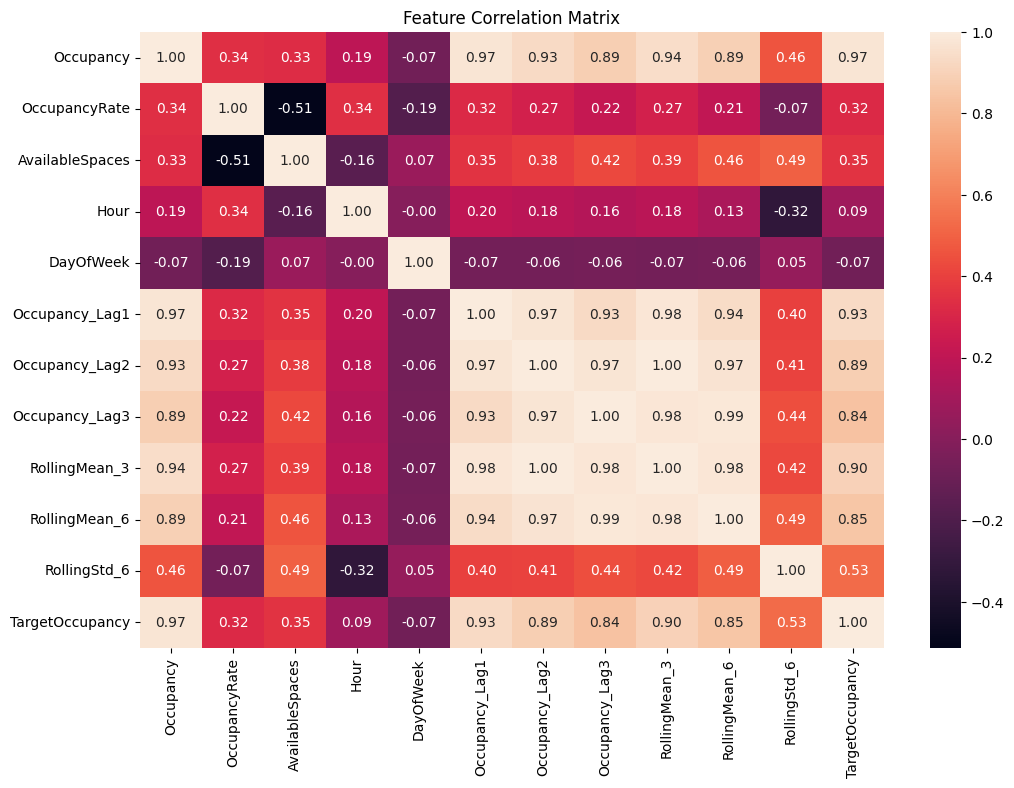

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [27]:
df.to_csv(
    "parking_features.csv",
    index=False
)